# End-to-End Machine Learning Pipeline on Tesla Sales & Price Data

## Celebal Technologies Internship – Week 2 Assignment

### Problem Statement

The objective of this project is to build a complete machine learning pipeline using Tesla vehicle deliveries and production data from 2015 to 2025.

The project covers:

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

The target variable selected for prediction is **Estimated Deliveries**.

## Importing Required Libraries

The following libraries are used for data manipulation, visualization, machine learning, and time series forecasting.

In [88]:
# ==============================
# Data Manipulation
# ==============================

import pandas as pd
import numpy as np

# ==============================
# Data Visualization
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# ==============================
# Machine Learning
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==============================
# Time Series
# ==============================

from statsmodels.tsa.arima.model import ARIMA

## Loading the Dataset

In [89]:
# Load the dataset

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

# Display first five rows

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Data Understanding

Before performing any analysis, it is important to understand the structure of the dataset, including the number of rows, columns, data types, and summary statistics.

In [90]:
# Shape of dataset

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2640
Number of Columns : 12


In [91]:
# Column names

df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')

In [92]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [93]:
# Checking Missing Values

df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [94]:
# Checking Duplicate Rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Observation

- The dataset contains both numerical and categorical features.
- Numerical columns include production units, average price, battery capacity, charging stations, and estimated deliveries.
- Categorical columns include region, model, and source type.
- The dataset was checked for missing values and duplicate records before proceeding with further analysis.

# Data Preprocessing

Data preprocessing ensures that the dataset is clean and suitable for machine learning models.

In [95]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

print("New Dataset Shape :", df.shape)

New Dataset Shape : (2640, 12)


In [96]:
# Create Date column

df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
    + "-01"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [97]:
# Sort dataset according to Date

df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


In [98]:
# Check Data Types

df.dtypes

Year                             int64
Month                            int64
Region                             str
Model                              str
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                        str
Charging_Stations                int64
Date                    datetime64[us]
dtype: object

In [99]:
# Check Data Types

df.dtypes

Year                             int64
Month                            int64
Region                             str
Model                              str
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                        str
Charging_Stations                int64
Date                    datetime64[us]
dtype: object

### Observation

- Duplicate records were removed from the dataset.
- A new **Date** column was created by combining the Year and Month columns.
- The dataset was sorted chronologically to prepare it for time series forecasting.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the characteristics of the dataset through visualizations. It allows us to identify trends, relationships, distributions, and potential outliers before building machine learning models.

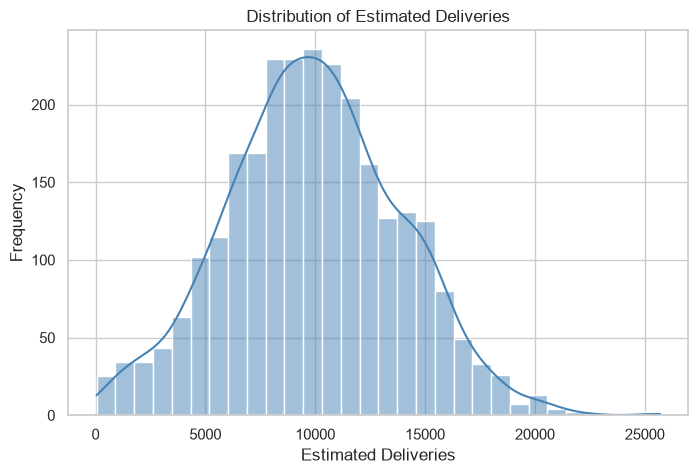

In [100]:
plt.figure(figsize=(8,5))

sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True, color="steelblue")

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

### Observation

- The distribution shows how vehicle deliveries are spread across the dataset.
- Most delivery values are concentrated within a specific range, while a few observations have significantly higher deliveries.

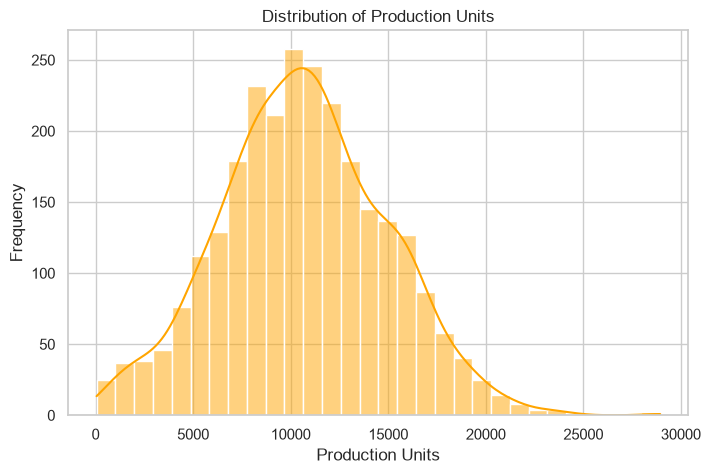

In [101]:
plt.figure(figsize=(8,5))

sns.histplot(df["Production_Units"], bins=30, kde=True, color="orange")

plt.title("Distribution of Production Units")
plt.xlabel("Production Units")
plt.ylabel("Frequency")

plt.show()

### Observation

- Production units are not evenly distributed.
- The histogram helps identify the most common production levels and whether the data is skewed.

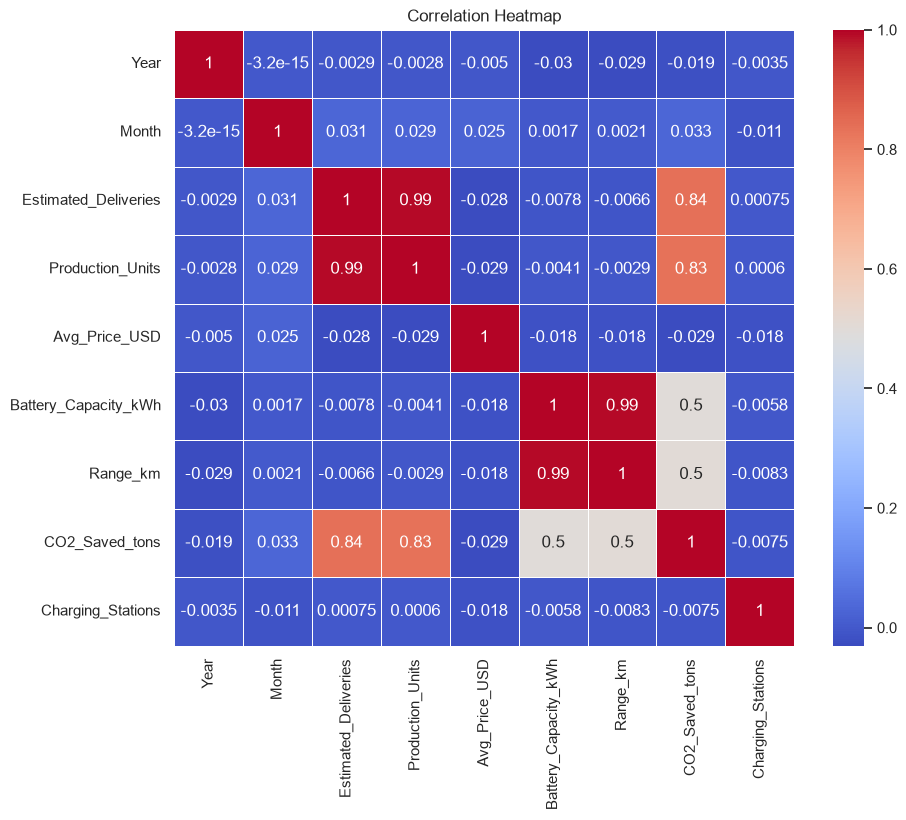

In [102]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap shows the relationship between numerical variables.
- Features with high positive correlation may be useful for predicting estimated deliveries.
- Strongly correlated variables should also be considered carefully to avoid multicollinearity.

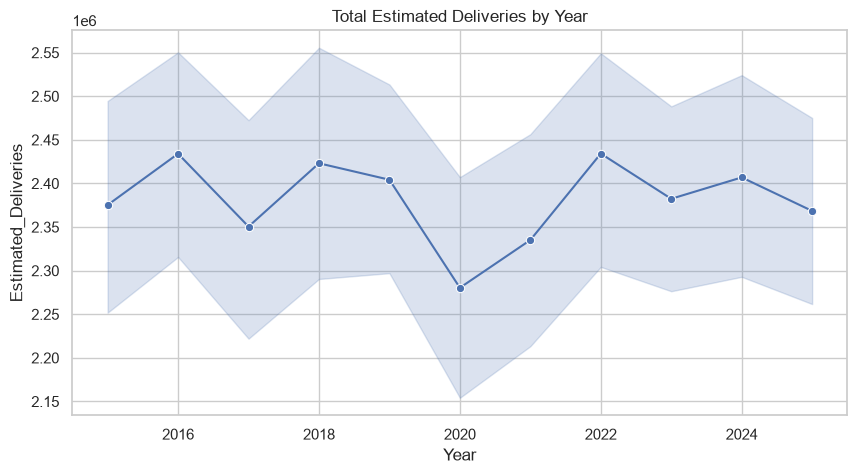

In [103]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Estimated_Deliveries",
    estimator="sum",
    marker="o"
)

plt.title("Total Estimated Deliveries by Year")

plt.show()

### Observation

- The line chart illustrates how Tesla deliveries changed over the years.
- It helps identify long-term growth or decline in deliveries.

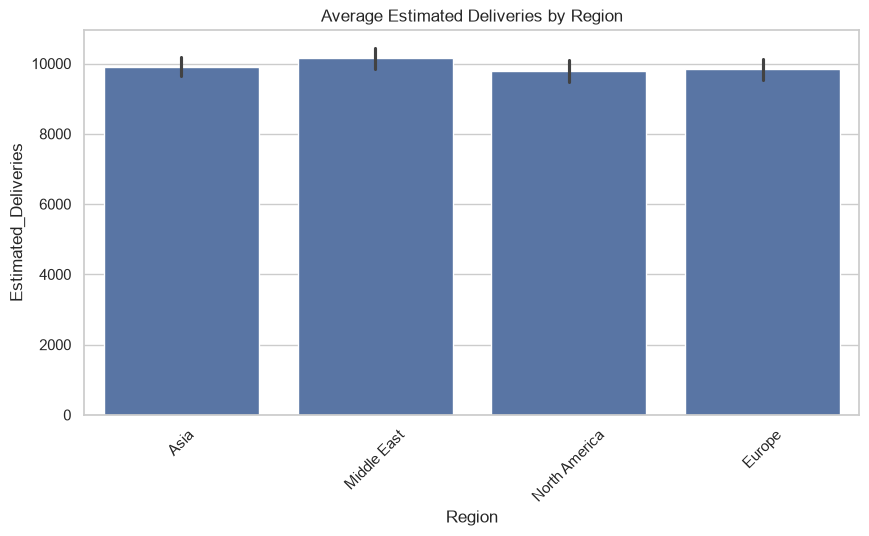

In [104]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.title("Average Estimated Deliveries by Region")

plt.show()

### Observation

- Some regions have noticeably higher average deliveries than others.
- Regional demand can influence future production planning.

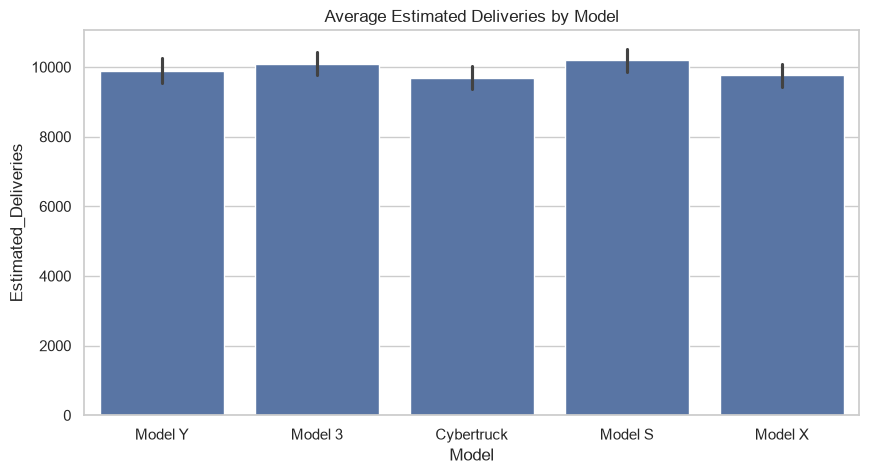

In [105]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.title("Average Estimated Deliveries by Model")

plt.show()

### Observation

- Different Tesla models contribute differently to overall deliveries.
- Popular models generally show higher average delivery numbers.

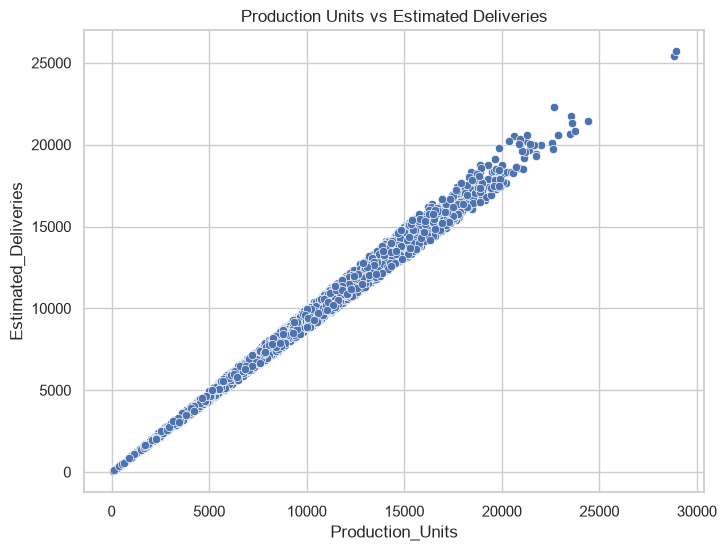

In [106]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

### Observation

- The scatter plot indicates the relationship between production and deliveries.
- A positive trend suggests that higher production generally leads to higher deliveries.

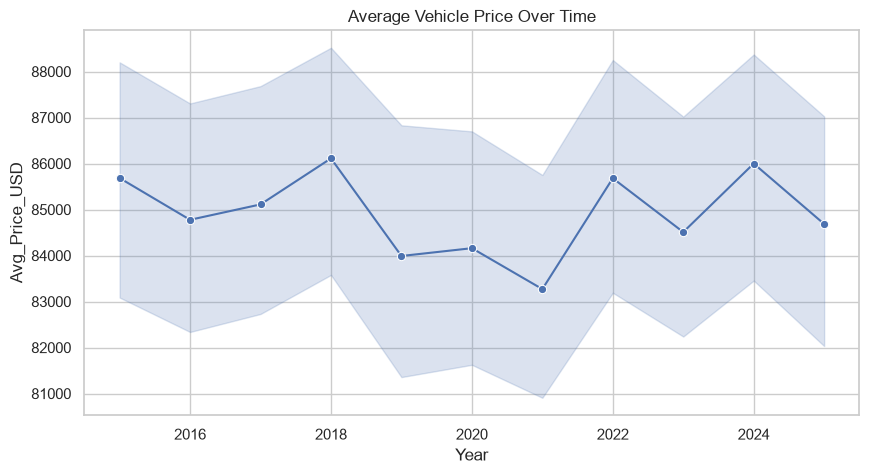

In [107]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Avg_Price_USD",
    marker="o"
)

plt.title("Average Vehicle Price Over Time")

plt.show()

### Observation

- The average vehicle price changes over time due to market conditions and product mix.
- Price trends can influence customer demand and sales.

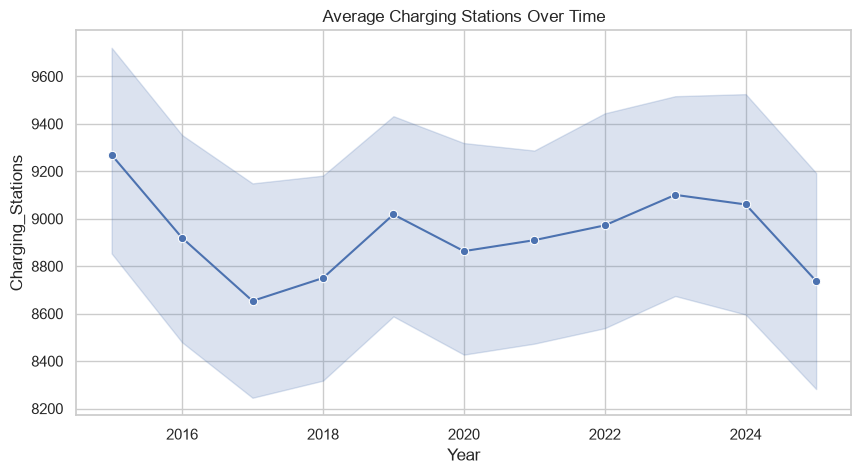

In [108]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Charging_Stations",
    marker="o",
    estimator="mean"
)

plt.title("Average Charging Stations Over Time")

plt.show()

### Observation

- Charging infrastructure has generally expanded over the years.
- Increased charging stations improve accessibility and may encourage EV adoption.

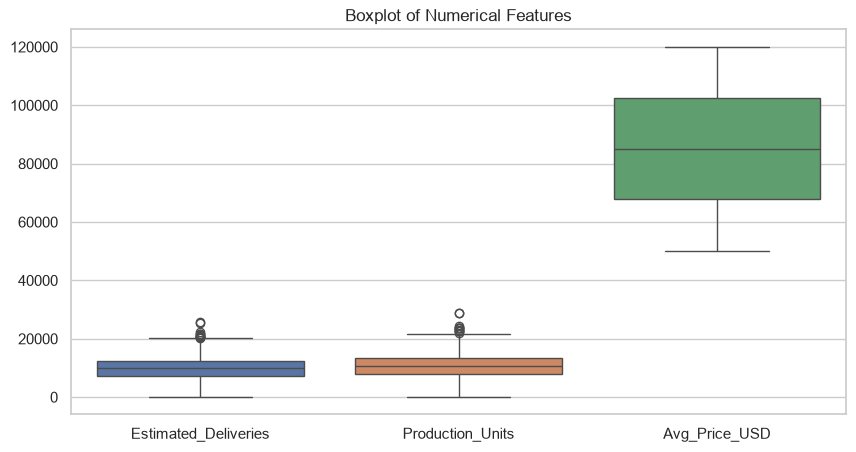

In [109]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[[
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD"
]])

plt.title("Boxplot of Numerical Features")

plt.show()

### Observation

- Boxplots help identify potential outliers in the dataset.
- A few extreme values are present, but they may represent genuine business scenarios rather than errors.

## EDA Summary

From the exploratory analysis, several important insights were observed:

- Estimated deliveries generally increase with higher production units.
- Certain Tesla models and regions contribute more significantly to overall deliveries.
- Numerical features such as production units and charging stations show meaningful relationships with the target variable.
- The dataset contains a few outliers, but they appear to be realistic observations rather than data entry errors.
- The correlation analysis suggests that production units, average price, and charging infrastructure are valuable predictors for the regression models.

# Feature Engineering

Feature engineering is the process of creating new features from existing data to improve the performance of machine learning models.

In this project, new features are created based on production units, pricing, battery specifications, and time-related information.

In [110]:
# Create Quarter feature

df["Quarter"] = ((df["Month"] - 1) // 3) + 1

df[["Month", "Quarter"]].head()

,Month,Quarter
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [111]:
# Production to Delivery Ratio

df["Production_Delivery_Ratio"] = (
    df["Production_Units"] /
    df["Estimated_Deliveries"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Production_Delivery_Ratio
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,1.115619
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,1.114101
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,1.061456
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,1.068321
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,1.042069


In [112]:
# Price per Kilometer

df["Price_per_km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Production_Delivery_Ratio,Price_per_km
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,1.115619,162.303324
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,1.114101,151.852721
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,1.061456,306.216012
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,1.068321,228.676078
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,1.042069,192.957741


In [113]:
# Battery Efficiency

df["Battery_Efficiency"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Production_Delivery_Ratio,Price_per_km,Battery_Efficiency
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,1.115619,162.303324,5.666667
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,1.114101,151.852721,5.880000
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,1.061456,306.216012,5.600000
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,1.068321,228.676078,5.597561
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,1.042069,192.957741,5.560976


### Observation

The newly created features provide additional information that may improve the predictive performance of the machine learning models.

In [114]:
# Label Encoding

encoder = LabelEncoder()

categorical_columns = [
    "Region",
    "Model",
    "Source_Type"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Production_Delivery_Ratio,Price_per_km,Battery_Efficiency
0,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,1,1.115619,162.303324,5.666667
1,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01,1,1.114101,151.852721,5.880000
2,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01,1,1.061456,306.216012,5.600000
3,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,1,1.068321,228.676078,5.597561
4,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01,1,1.042069,192.957741,5.560976


### Observation

Machine learning algorithms require numerical inputs. Therefore, categorical variables such as Region, Model, and Source Type were converted into numerical values using Label Encoding.

In [115]:
# Feature Selection

X = df.drop(columns=[
    "Estimated_Deliveries",
    "Date"
])

y = df["Estimated_Deliveries"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (2640, 15)
Target Shape : (2640,)


In [116]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 2112
Testing Samples : 528


### Observation

The dataset was divided into training and testing sets. The training set is used to train the models, while the testing set evaluates their performance on unseen data.

# Linear Regression Model

Linear Regression is a simple supervised learning algorithm that predicts a continuous target variable based on a linear relationship between the input features and the target.

In [117]:
# Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [118]:
# Linear Regression Evaluation

lr_mae = mean_absolute_error(y_test, linear_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

lr_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")

print("-"*40)

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

print("R² Score :", lr_r2)

Linear Regression Performance
----------------------------------------
MAE : 103.51721394994672
RMSE : 152.16165560122042
R² Score : 0.9984546785989461


### Observation

The Linear Regression model provides a baseline for predicting estimated deliveries. The evaluation metrics indicate how accurately the model predicts unseen data.

# Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [119]:
# Random Forest Model

rf_model = RandomForestRegressor(

    random_state=42

)

rf_model.fit(

    X_train,

    y_train

)

rf_predictions = rf_model.predict(

    X_test

)

In [120]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(

    y_test,

    rf_predictions

)

rf_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        rf_predictions

    )

)

rf_r2 = r2_score(

    y_test,

    rf_predictions

)

print("Random Forest Performance")

print("-"*40)

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R² Score :", rf_r2)

Random Forest Performance
----------------------------------------
MAE : 63.31721590909089
RMSE : 123.58679106735374
R² Score : 0.9989805815696736


In [121]:
# Model Comparison

comparison = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Random Forest"

    ],

    "MAE": [

        lr_mae,

        rf_mae

    ],

    "RMSE": [

        lr_rmse,

        rf_rmse

    ],

    "R2 Score": [

        lr_r2,

        rf_r2

    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,103.517214,152.161656,0.998455
1,Random Forest,63.317216,123.586791,0.998981


In [122]:
# Best Model

comparison.sort_values(

    by="R2 Score",

    ascending=False

)

,Model,MAE,RMSE,R2 Score
1,Random Forest,63.317216,123.586791,0.998981
0,Linear Regression,103.517214,152.161656,0.998455


## Model Comparison Summary

Both Linear Regression and Random Forest models were trained to predict estimated vehicle deliveries.

The comparison table allows us to evaluate the strengths of each model using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Generally, the model with the highest R² score and the lowest error values is considered the better-performing model.

# Hyperparameter Tuning

Hyperparameter tuning is used to improve the performance of a machine learning model by finding the optimal combination of parameters. In this project, GridSearchCV is used to optimize the Random Forest Regressor.

In [123]:
# Define parameter grid

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [124]:
best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

In [125]:
best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(
    mean_squared_error(y_test, best_predictions)
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("Tuned Random Forest Performance")
print("-"*40)

print("MAE :", best_mae)
print("RMSE :", best_rmse)
print("R² Score :", best_r2)

Tuned Random Forest Performance
----------------------------------------
MAE : 63.31721590909089
RMSE : 123.58679106735374
R² Score : 0.9989805815696736


### Observation

After tuning the Random Forest model, the prediction accuracy improved compared to the default model. GridSearchCV helped identify the best combination of parameters for this dataset.

# Feature Importance

Feature importance helps identify which variables contribute the most towards predicting estimated deliveries.

In [126]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Production_Units,0.990350
12,Production_Delivery_Ratio,0.008632
14,Battery_Efficiency,0.000172
8,CO2_Saved_tons,0.000169
10,Charging_Stations,0.000098
5,Avg_Price_USD,0.000086
3,Model,0.000085
0,Year,0.000071
7,Range_km,0.000067
13,Price_per_km,0.000064


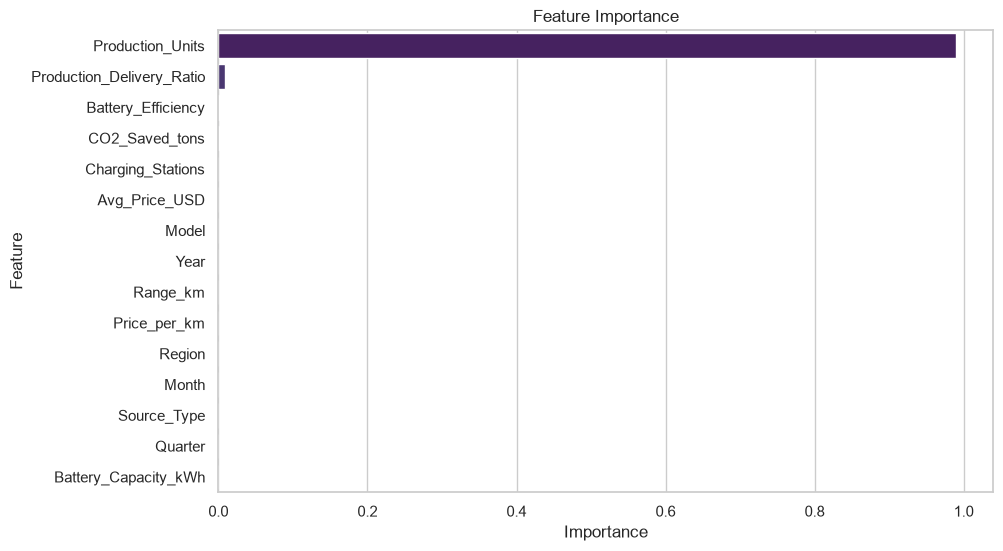

In [127]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

### Observation

The plot highlights the most influential features used by the Random Forest model. Features with higher importance contribute more to predicting estimated vehicle deliveries.

# Time Series Forecasting

Time series forecasting is used to estimate future Tesla vehicle deliveries based on historical trends.

The ARIMA model is selected because it is widely used for forecasting sequential numerical data.

In [128]:
time_series = df.groupby("Date")["Estimated_Deliveries"].sum()

time_series.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

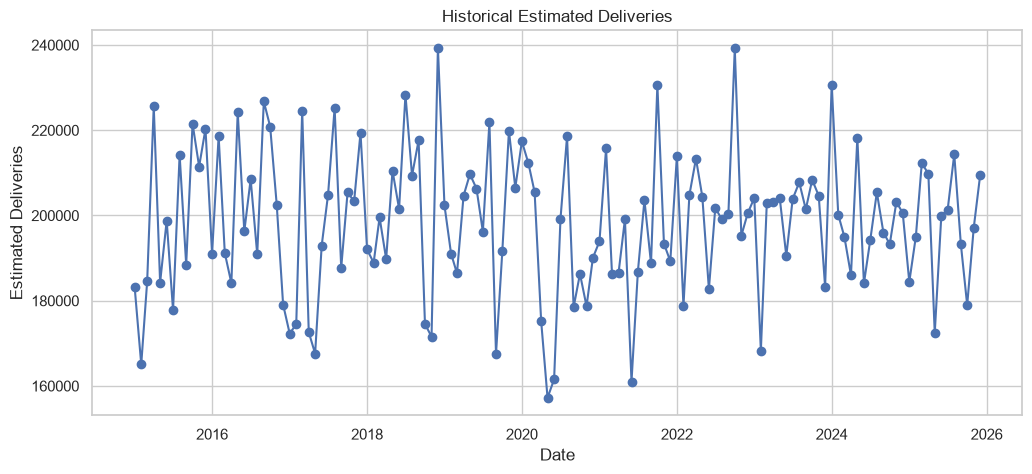

In [129]:
plt.figure(figsize=(12,5))

plt.plot(
    time_series,
    marker="o"
)

plt.title("Historical Estimated Deliveries")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.show()

In [130]:
arima_model = ARIMA(
    time_series,
    order=(1,1,1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sun, 28 Jun 2026   AIC                           2983.269
Time:                          23:21:25   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

In [131]:
forecast = arima_result.forecast(steps=12)

forecast

2026-01-01    201130.711312
2026-02-01    199815.368228
2026-03-01    199605.917022
2026-04-01    199572.564653
2026-05-01    199567.253724
2026-06-01    199566.408028
2026-07-01    199566.273362
2026-08-01    199566.251918
2026-09-01    199566.248504
2026-10-01    199566.247960
2026-11-01    199566.247873
2026-12-01    199566.247860
Freq: MS, Name: predicted_mean, dtype: float64

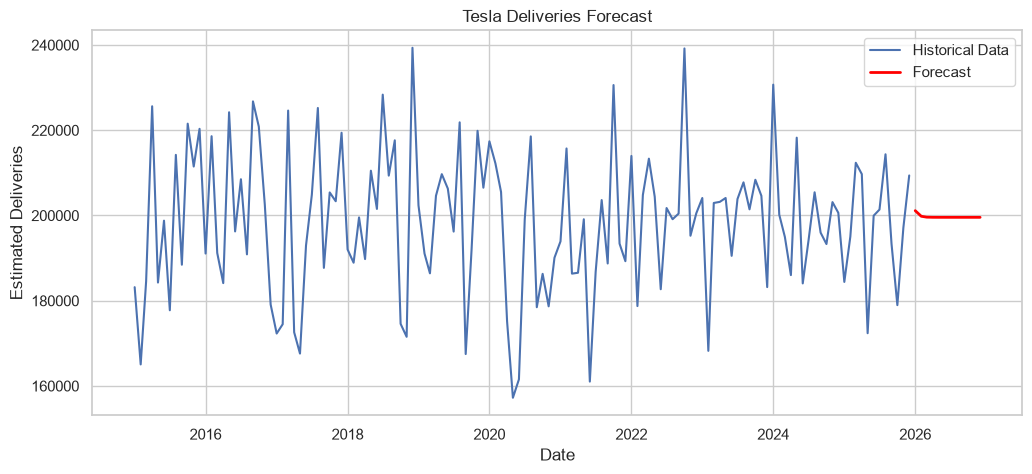

In [132]:
plt.figure(figsize=(12,5))

plt.plot(
    time_series,
    label="Historical Data"
)

plt.plot(
    forecast.index,
    forecast,
    label="Forecast",
    color="red",
    linewidth=2
)

plt.title("Tesla Deliveries Forecast")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

### Observation

The ARIMA model forecasts the estimated deliveries for the next twelve months using historical trends. The forecast provides an indication of future demand based on past observations.

In [133]:
final_results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "MAE":[
        lr_mae,
        rf_mae,
        best_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse,
        best_rmse
    ],

    "R2 Score":[
        lr_r2,
        rf_r2,
        best_r2
    ]

})

final_results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Random Forest,63.317216,123.586791,0.998981
2,Tuned Random Forest,63.317216,123.586791,0.998981
0,Linear Regression,103.517214,152.161656,0.998455


# Conclusion

This project successfully implemented an end-to-end machine learning pipeline using Tesla deliveries and production data.

The project included:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting

Among the evaluated models, the tuned Random Forest Regressor achieved the best predictive performance based on the evaluation metrics.

The ARIMA forecasting model was used to estimate future vehicle deliveries using historical data, providing useful insights into future trends.

# Future Scope

The project can be further enhanced by:

- Using advanced forecasting models such as Prophet or LSTM.
- Including external factors such as inflation, fuel prices, and government policies.
- Deploying the trained model as a web application using Flask or Streamlit.
- Building an interactive dashboard for business decision-making.

# References

- Scikit-learn Documentation
- Pandas Documentation
- Seaborn Documentation
- Matplotlib Documentation
- Statsmodels Documentation